<a href="https://colab.research.google.com/github/laura2ndrea/Campuslands_CampusApp/blob/main/Proyecto_01_Laura_Andrea_Rodr%C3%ADguez_Mej%C3%ADa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 01 — Solución númerica de ecuaciones diferenciales de primer orden

## Solución numérica del enfriamiento de un cuerpo metálico con convección natural y radiación térmica

**- Estudiante:** Laura Andrea Rodríguez Mejía

**- Código:** 2191822

**- Curso:** Ecuaciones diferenciales - Grupo C4

**- Semestre:** 2026 - 01

**- Universidad:** Universidad Industrial de Santander (UIS), Sede Bucaramanga

**- Docente:** Julio César Carrillo Escobar

---

## Resumen

En este proyecto se plantea, justifica y resuelve numéricamente un problema de valor inicial (PVI) no lineal asociado al enfriamiento transitorio de un sólido metálico que pierde energía simultáneamente por convección natural y por radiación térmica hacia el ambiente. Se implementan desde cero los métodos de Euler explícito, Runge–Kutta de segundo orden (Heun) y Runge–Kutta clásico de cuarto orden (RK4), se deduce formalmente su error local de truncamiento (ETL) a partir de series de Taylor y se realiza un estudio empírico de convergencia en norma del supremo comparando contra una solución de referencia obtenida con `scipy.integrate.solve_ivp` a tolerancia $10^{-12}$.


## 1. Planteamiento y justificación física del PVI

### 1.1 Contexto físico

Considérese una pieza metálica pequeña (acero forjado) que, tras un proceso de tratamiento térmico, se encuentra inicialmente a $T_0 = 1000\ \mathrm{K}$ y se deja enfriar en aire quieto a temperatura ambiente $T_\infty = 300\ \mathrm{K}$. La pieza pierde energía por dos mecanismos simultáneos:

1. **Convección natural** con el aire circundante, siguiendo la ley de Newton del enfriamiento.
2. **Radiación térmica** hacia el entorno, siguiendo la ley de Stefan–Boltzmann.

### 1.2 Hipótesis de capacitancia agrupada (*lumped capacitance*)

Se asume que la temperatura $T$ es espacialmente uniforme dentro del sólido en todo instante, de modo que $T = T(t)$ solamente. Esta hipótesis es válida cuando el número de Biot satisface

$$
\mathrm{Bi} \;=\; \dfrac{h\, L_c}{k_{\text{sólido}}} \;\ll\; 0.1,
$$

donde $L_c = V/A$ es la longitud característica del cuerpo (Bergman et al., 2011). Para un cubo de lado $L=0.05\ \mathrm{m}$ de acero ($k_{\text{sólido}} \approx 50\ \mathrm{W/(m\cdot K)}$), con $h \approx 20\ \mathrm{W/(m^2\cdot K)}$ y $L_c = L/6$:

$$
\mathrm{Bi} \;=\; \dfrac{20 \cdot (0.05/6)}{50} \;\approx\; 3.33\times 10^{-3} \;\ll\; 0.1,
$$

por lo que la hipótesis es ampliamente satisfecha y la temperatura puede modelarse con una sola EDO ordinaria en el tiempo.

### 1.3 Balance de energía y ecuación diferencial

Aplicando la primera ley de la termodinámica al sólido (sin generación interna):

$$
\underbrace{m\,c\,\dfrac{dT}{dt}}_{\text{variación de energía interna}} \;=\; -\,\underbrace{h A (T - T_\infty)}_{\text{convección}} \;-\; \underbrace{\varepsilon\, \sigma\, A\,(T^4 - T_\infty^4)}_{\text{radiación}}.
$$

Dividiendo entre $m c$ y definiendo los coeficientes agrupados

$$
k_1 \;=\; \dfrac{h A}{m c}, \qquad k_2 \;=\; \dfrac{\varepsilon\, \sigma\, A}{m c},
$$

el problema de valor inicial queda:

$$
\boxed{\;\dfrac{dT}{dt} \;=\; -\,k_1\,(T-T_\infty)\;-\;k_2\,(T^4-T_\infty^4), \qquad T(0)=T_0.\;}
$$

### 1.4 Análisis de los términos: ¿domina la no linealidad?

Nótese que el término radiativo es $\propto T^4$, lo que introduce una fuerte no linealidad a altas temperaturas. Para valorar su importancia relativa en el instante inicial, se calcula la razón adimensional

$$
\mathcal{R}(t) \;=\; \dfrac{\varepsilon\,\sigma\,(T^4 - T_\infty^4)}{h\,(T - T_\infty)}.
$$

Con los valores de la tabla de parámetros (§1.6):

$$
\mathcal{R}(0) \;=\; \dfrac{0.8 \cdot 5.67\times 10^{-8}\,(1000^4-300^4)}{20\,(1000-300)} \;\approx\; 3.21.
$$

Es decir, a $t=0$ el flujo radiativo es más de tres veces mayor que el convectivo, por lo que linealizar o ignorar la no linealidad sería un error modelístico grave. Este es precisamente el rango donde los métodos numéricos de alto orden muestran su valor frente a aproximaciones ingenuas.

### 1.5 ¿Por qué necesitamos métodos numéricos? (no existe forma cerrada)

La ecuación es separable:

$$
\int_{T_0}^{T(t)} \dfrac{dT}{-k_1(T-T_\infty) - k_2(T^4-T_\infty^4)} \;=\; \int_0^t d\tau.
$$

El denominador es un polinomio de grado $4$ en $T$. Factorizando:

$$
P(T) \;=\; k_2(T^4-T_\infty^4) + k_1(T-T_\infty) \;=\; (T-T_\infty)\Bigl[\,k_2(T+T_\infty)(T^2+T_\infty^2) + k_1\Bigr].
$$

El segundo factor es el polinomio cúbico

$$
Q(T) \;=\; k_2 T^3 + k_2 T_\infty T^2 + k_2 T_\infty^2 T + (k_2 T_\infty^3 + k_1).
$$

Su derivada es $Q'(T) = 3 k_2 T^2 + 2 k_2 T_\infty T + k_2 T_\infty^2$, cuyo discriminante vale $4 k_2^2 T_\infty^2 - 12 k_2^2 T_\infty^2 = -8 k_2^2 T_\infty^2 < 0$. Luego $Q'$ no tiene raíces reales y $Q$ es estrictamente monótona creciente, de donde se sigue que $Q$ posee una única raíz real (negativa, sin significado físico) y dos raíces complejas conjugadas. La descomposición en fracciones parciales obliga entonces a incluir un factor cuadrático irreducible cuya primitiva involucra funciones $\arctan$ con argumentos acoplados a $k_1$, $k_2$ y $T_\infty$, y cuya inversión analítica para despejar $T(t)$ no puede expresarse en funciones elementales de forma cerrada manejable. Por lo tanto, los métodos numéricos no son una comodidad sino una necesidad.**

### 1.6 Parámetros físicos del problema

| Símbolo | Valor | Unidades | Significado |
|---|---|---|---|
| $T_0$ | $1000$ | K | Temperatura inicial del sólido |
| $T_\infty$ | $300$ | K | Temperatura del aire ambiente |
| $h$ | $20$ | W/(m²·K) | Coeficiente de convección natural en aire |
| $\varepsilon$ | $0.8$ | — | Emisividad de acero oxidado |
| $\sigma$ | $5.67\times10^{-8}$ | W/(m²·K⁴) | Constante de Stefan–Boltzmann |
| $\rho$ | $7850$ | kg/m³ | Densidad del acero |
| $c$ | $500$ | J/(kg·K) | Calor específico del acero |
| $L$ | $0.05$ | m | Lado del cubo |
| $A = 6L^2$ | $1.5\times10^{-2}$ | m² | Área superficial total |
| $m = \rho L^3$ | $\approx 0.981$ | kg | Masa del sólido |
| $t_f$ | $600$ | s | Horizonte de simulación |


## 2. Marco teórico: deducción formal del error

Sea el PVI $y'(t)=f(t,y)$, $y(t_0)=y_0$, con solución exacta $y(t)$ suficientemente diferenciable. Sea $t_n = t_0 + n h$ y $y_n$ la aproximación numérica en $t_n$. Se define el **error local de truncamiento** (ETL) como

$$
\tau_{n+1} \;=\; \dfrac{y(t_{n+1}) - \Phi\bigl(t_n,\,y(t_n);\,h\bigr)}{h},
$$

donde $\Phi$ es el operador de avance del método. Se dice que el método es de orden $p$ si $\tau_{n+1} = \mathcal{O}(h^p)$.

### 2.1 Euler explícito

El esquema es $y_{n+1} = y_n + h\,f(t_n, y_n)$. Expandiendo la solución exacta $y(t_{n+1})$ en serie de Taylor alrededor de $t_n$:

$$
y(t_{n+1}) \;=\; y(t_n) + h\,y'(t_n) + \dfrac{h^2}{2}\,y''(\xi_n), \qquad \xi_n \in (t_n,\,t_{n+1}).
$$

Restando el avance del método (y usando que $f(t_n,y(t_n))=y'(t_n)$):

$$
y(t_{n+1}) - y_{n+1}^{(\text{Euler})} \;=\; \dfrac{h^2}{2}\,y''(\xi_n).
$$

Dividiendo entre $h$, el ETL resulta:

$$
\boxed{\;\tau_{n+1}^{(\text{Euler})} \;=\; \dfrac{h}{2}\,y''(\xi_n) \;=\; \mathcal{O}(h),\qquad \text{orden}\ p = 1.\;}
$$

### 2.2 Runge–Kutta de segundo orden (Heun)

El esquema es:

$$
k_1 = f(t_n, y_n), \qquad k_2 = f(t_n + h,\; y_n + h k_1), \qquad y_{n+1} = y_n + \tfrac{h}{2}\,(k_1 + k_2).
$$

Expandiendo $k_2$ en serie de Taylor bivariada alrededor de $(t_n,y_n)$:

$$
k_2 \;=\; f + h\, f_t + h\,f\,f_y + \dfrac{h^2}{2}\bigl(f_{tt} + 2 f\,f_{ty} + f^2 f_{yy}\bigr) + \mathcal{O}(h^3),
$$

donde $f$ y sus derivadas se evalúan en $(t_n,y_n)$. Sustituyendo:

$$
y_{n+1}^{(\text{RK2})} \;=\; y_n + h\,f + \dfrac{h^2}{2}\,(f_t + f\,f_y) + \dfrac{h^3}{4}\,(f_{tt} + 2 f f_{ty} + f^2 f_{yy}) + \mathcal{O}(h^4).
$$

La serie de Taylor de la solución exacta satisface $y' = f$, $y'' = f_t + f f_y$ y $y''' = f_{tt} + 2 f f_{ty} + f^2 f_{yy} + f_y(f_t + f f_y)$. Comparando término a término:

- Los términos de orden $h$ y $h^2$ se cancelan idénticamente entre el esquema y la expansión exacta.
- En orden $h^3$ aparece la discrepancia $\tfrac{h^3}{4}(\cdots) - \tfrac{h^3}{6}\, y''' \neq 0$ en general.

Luego:

$$
\boxed{\;\tau_{n+1}^{(\text{RK2})} \;=\; \mathcal{O}(h^2),\qquad \text{orden}\ p = 2.\;}
$$

### 2.3 Runge–Kutta clásico de cuarto orden (RK4)

El esquema es:

$$
\begin{aligned}
k_1 &= f(t_n,\, y_n), \\
k_2 &= f\!\bigl(t_n + \tfrac{h}{2},\; y_n + \tfrac{h}{2} k_1\bigr), \\
k_3 &= f\!\bigl(t_n + \tfrac{h}{2},\; y_n + \tfrac{h}{2} k_2\bigr), \\
k_4 &= f(t_n + h,\; y_n + h k_3), \\
y_{n+1} &= y_n + \tfrac{h}{6}\,(k_1 + 2 k_2 + 2 k_3 + k_4).
\end{aligned}
$$

La deducción directa por Taylor bivariado es tediosa; en la práctica se recurre al formalismo de los árboles con raíz y las condiciones de orden, donde cada término de la serie de Taylor de la solución exacta se identifica con un árbol con raíz (*rooted tree*) y los coeficientes del método deben satisfacer las llamadas condiciones de orden. Para alcanzar orden $4$ se requieren $8$ condiciones de orden (árboles de hasta $4$ vértices), que el RK4 clásico satisface exactamente. Esto garantiza la cancelación de todos los términos hasta $h^4$ en la diferencia $y(t_{n+1}) - y_{n+1}$, dejando:

$$
\boxed{\;\tau_{n+1}^{(\text{RK4})} \;=\; \mathcal{O}(h^4),\qquad \text{orden}\ p = 4.\;}
$$

### 2.4 Del ETL al error global: teorema de convergencia

Vale la pena destacar que el ETL mide el error en un solo paso, mientras que lo que realmente importa al usuario es el **error global** $E_n = |y(t_n) - y_n|$ acumulado tras $n$ pasos. La conexión formal entre ambos la establece el siguiente resultado clásico:

**Teorema (Lax–Richtmyer, versión para métodos de un paso).** *Sea $\Phi$ un método de un paso consistente de orden $p$ (es decir, $\tau_{n+1} = \mathcal{O}(h^p)$) y Lipschitz-estable respecto a $y$ con constante $L$. Entonces, para todo $t_n \in [t_0, t_f]$ fijo y $h \to 0^+$, el error global satisface:*

$$
\boxed{\;E_n \;\le\; \dfrac{M}{L}\,\bigl(e^{L(t_n - t_0)} - 1\bigr)\, h^p \;=\; \mathcal{O}(h^p),\;}
$$

*donde $M$ es una cota uniforme de $|\tau_{n+1}|/h^{p}$ en el intervalo considerado.*

Este teorema implica que un método de orden $p$ tiene error global $\mathcal{O}(h^p)$. En consecuencia, las pendientes esperadas en la gráfica log-log de $E(h)$ vs. $h$ son:

| Método | Pendiente teórica | Factor $E(h)/E(h/2)$ esperado |
|:---:|:---:|:---:|
| Euler | $1$ | $2$ |
| RK2   | $2$ | $4$ |
| RK4   | $4$ | $16$ |

Nótese que la constante $\tfrac{M}{L}\bigl(e^{L(t_f-t_0)}-1\bigr)$ puede ser grande si el intervalo es largo o si $L$ es grande, pero la pendiente en log-log es independiente de estos factores. Esto es precisamente lo que se verifica empíricamente en la §5.


## 3. Implementación computacional

A continuación se construye el código del proyecto:


In [ ]:
# --- Librerías necesarias ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Estilo para las gráficas ---
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.dpi"]        = 120
plt.rcParams["savefig.dpi"]       = 120
plt.rcParams["axes.titleweight"]  = "bold"
plt.rcParams["axes.labelsize"]    = 11
plt.rcParams["legend.fontsize"]   = 10


In [ ]:
# --- Parámetros físicos del problema ---
T0       = 1000.0      # [K]            Temperatura inicial del sólido
T_INF    = 300.0       # [K]            Temperatura del aire ambiente
H_CONV   = 20.0        # [W/(m^2·K)]    Coef. de convección natural (aire tranquilo)
EPS      = 0.8         # [-]            Emisividad de acero oxidado
SIGMA    = 5.67e-8     # [W/(m^2·K^4)]  Constante de Stefan–Boltzmann
RHO      = 7850.0      # [kg/m^3]       Densidad del acero
C_ESP    = 500.0       # [J/(kg·K)]     Calor específico del acero
L_LADO   = 0.05        # [m]            Lado del cubo sólido
K_SOL    = 50.0        # [W/(m·K)]      Conductividad térmica del acero (para Biot)

# --- Geometría derivada ---
AREA     = 6.0 * L_LADO**2    # [m^2]  Área superficial del cubo
MASA     = RHO * L_LADO**3    # [kg]   Masa del cubo
LC       = L_LADO / 6.0       # [m]    Longitud característica V/A

# --- Coeficientes agrupados del modelo ---
# Reducen la EDO a dos constantes efectivas que encapsulan toda la geometría.
K1 = H_CONV * AREA / (MASA * C_ESP)            # [1/s]        coef. convectivo
K2 = EPS * SIGMA * AREA / (MASA * C_ESP)       # [1/(s·K^3)]  coef. radiativo

# --- Horizonte temporal de simulación ---
T_INICIAL = 0.0        # [s]
T_FINAL   = 600.0      # [s]   10 minutos de enfriamiento

# --- Verificación de la hipótesis de capacitancia agrupada ---
BIOT = H_CONV * LC / K_SOL
print("\n[Validación de la hipótesis de lumped capacitance]")
print(f"  Número de Biot  Bi = h·Lc/k = {BIOT:.4e}   (requerido Bi < 0.1) "
      f"-->  {'OK' if BIOT < 0.1 else 'HIPÓTESIS NO VÁLIDA'}")

# --- Razón radiación / convección en el instante inicial ---
razon_rad_conv = (EPS * SIGMA * (T0**4 - T_INF**4)) / (H_CONV * (T0 - T_INF))
print("\n[Análisis de términos en t = 0]")
print(f"  R(0) = q_rad / q_conv = {razon_rad_conv:.3f}")
print(f"  --> La no linealidad radiativa domina por un factor ≈ {razon_rad_conv:.1f}.")

# --- Coeficientes agrupados ---
print("\n[Coeficientes agrupados]")
print(f"  K1 = h·A/(m·c)      = {K1:.4e}  [1/s]")
print(f"  K2 = ε·σ·A/(m·c)    = {K2:.4e}  [1/(s·K^3)]")
print(f"  Masa del cubo        = {MASA:.4f} kg")
print(f"  Área superficial     = {AREA:.4f} m^2")



[Validación de la hipótesis de lumped capacitance]
  Número de Biot  Bi = h·Lc/k = 3.3333e-03   (requerido Bi < 0.1) -->  OK

[Análisis de términos en t = 0]
  R(0) = q_rad / q_conv = 3.214
  --> La no linealidad radiativa domina por un factor ≈ 3.2.

[Coeficientes agrupados]
  K1 = h·A/(m·c)      = 6.1146e-04  [1/s]
  K2 = ε·σ·A/(m·c)    = 1.3868e-12  [1/(s·K^3)]
  Masa del cubo        = 0.9813 kg
  Área superficial     = 0.0150 m^2


In [ ]:
# Función f(t, T) que define el PVI
#     dT/dt = -K1 (T - T_inf) - K2 (T^4 - T_inf^4)

def f_modelo(t, T):
    """
    Lado derecho del PVI de enfriamiento con convección + radiación.

    Parámetros
    ----------
    t : float
        Tiempo [s]. La EDO es autónoma, pero se mantiene la firma (t, T) por
        compatibilidad con los métodos numéricos y con scipy.solve_ivp.
    T : float o np.ndarray
        Temperatura del sólido [K].

    Retorna
    -------
    dTdt : mismo tipo que T
        Derivada temporal de la temperatura [K/s].
    """
    return -K1 * (T - T_INF) - K2 * (T**4 - T_INF**4)

# Verificación manual paso a paso en t = 0, T = T0 = 1000 K
# (demuestra la correcta codificación del modelo y da intuición numérica)

print("Verificación manual de f_modelo(0, 1000)")
print("-" * 60)

termino_conv = -K1 * (T0 - T_INF)
termino_rad  = -K2 * (T0**4 - T_INF**4)
manual       = termino_conv + termino_rad
automatico   = f_modelo(0.0, T0)

print(f"  Término convectivo = -K1·(T - T_inf)")
print(f"                     = -({K1:.4e})·({T0} - {T_INF})")
print(f"                     = {termino_conv:+.6f}  K/s")
print(f"  Término radiativo  = -K2·(T^4 - T_inf^4)")
print(f"                     = -({K2:.4e})·({T0**4:.3e} - {T_INF**4:.3e})")
print(f"                     = {termino_rad:+.6f}  K/s")
print(f"  Suma (cálculo manual) : {manual:+.6f} K/s")
print(f"  f_modelo(0, 1000)     : {automatico:+.6f} K/s")
print(f"  |diferencia|          : {abs(manual - automatico):.2e}   -->  OK")


Verificación manual de f_modelo(0, 1000)
------------------------------------------------------------
  Término convectivo = -K1·(T - T_inf)
                     = -(6.1146e-04)·(1000.0 - 300.0)
                     = -0.428025  K/s
  Término radiativo  = -K2·(T^4 - T_inf^4)
                     = -(1.3868e-12)·(1.000e+12 - 8.100e+09)
                     = -1.375569  K/s
  Suma (cálculo manual) : -1.803595 K/s
  f_modelo(0, 1000)     : -1.803595 K/s
  |diferencia|          : 0.00e+00   -->  OK


In [ ]:
# --- Implementación de los métodos numéricos  ---
# Nota sobre vectorización:
#     Los bucles `for` en el lazo temporal son inevitables porque cada paso
#     depende secuencialmente del valor anterior (y_{n+1} usa y_n). Esta
#     dependencia imposibilita la vectorización total del lazo temporal. Sí
#     se aprovecha NumPy para la representación de arreglos y la aritmética.

def euler(f, t0, tf, y0, h):
    """
    Método de Euler explícito (orden 1).

    Esquema numérico:
        y_{n+1} = y_n + h · f(t_n, y_n)

    Parámetros
    ----------
    f  : callable   Función f(t, y) lado derecho de la EDO.
    t0 : float      Tiempo inicial.
    tf : float      Tiempo final.
    y0 : float      Condición inicial y(t0).
    h  : float      Paso de integración.

    Retorna
    -------
    t : np.ndarray  Malla temporal uniforme de tamaño N+1.
    y : np.ndarray  Solución numérica evaluada en t, tamaño N+1.
    """
    N = int(round((tf - t0) / h))                  # Número de pasos
    t = np.linspace(t0, t0 + N * h, N + 1)         # Malla temporal uniforme
    y = np.empty(N + 1)                            # Reserva de memoria
    y[0] = y0                                      # Condición inicial
    for n in range(N):                             # Iteración secuencial
        y[n + 1] = y[n] + h * f(t[n], y[n])        # Fórmula de Euler
    return t, y


def rk2(f, t0, tf, y0, h):
    """
    Método de Runge–Kutta de 2.º orden (Heun / trapecio explícito).

    Esquema numérico:
        k1      = f(t_n, y_n)
        k2      = f(t_n + h, y_n + h·k1)
        y_{n+1} = y_n + (h/2)·(k1 + k2)

    Parámetros
    ----------
    f  : callable   Función f(t, y) lado derecho de la EDO.
    t0 : float      Tiempo inicial.
    tf : float      Tiempo final.
    y0 : float      Condición inicial y(t0).
    h  : float      Paso de integración.

    Retorna
    -------
    t : np.ndarray  Malla temporal uniforme de tamaño N+1.
    y : np.ndarray  Solución numérica evaluada en t, tamaño N+1.
    """
    N = int(round((tf - t0) / h))
    t = np.linspace(t0, t0 + N * h, N + 1)
    y = np.empty(N + 1)
    y[0] = y0
    for n in range(N):                              # Iteración secuencial
        k1 = f(t[n], y[n])                          # Pendiente al inicio del paso
        k2 = f(t[n] + h, y[n] + h * k1)             # Pendiente al final (predictor)
        y[n + 1] = y[n] + 0.5 * h * (k1 + k2)       # Corrector: promedio
    return t, y


def rk4(f, t0, tf, y0, h):
    """
    Método clásico de Runge–Kutta de 4.º orden.

    Esquema numérico:
        k1      = f(t_n, y_n)
        k2      = f(t_n + h/2, y_n + (h/2)·k1)
        k3      = f(t_n + h/2, y_n + (h/2)·k2)
        k4      = f(t_n + h,   y_n + h·k3)
        y_{n+1} = y_n + (h/6)·(k1 + 2·k2 + 2·k3 + k4)

    Parámetros
    ----------
    f  : callable   Función f(t, y) lado derecho de la EDO.
    t0 : float      Tiempo inicial.
    tf : float      Tiempo final.
    y0 : float      Condición inicial y(t0).
    h  : float      Paso de integración.

    Retorna
    -------
    t : np.ndarray  Malla temporal uniforme de tamaño N+1.
    y : np.ndarray  Solución numérica evaluada en t, tamaño N+1.
    """
    N = int(round((tf - t0) / h))
    t = np.linspace(t0, t0 + N * h, N + 1)
    y = np.empty(N + 1)
    y[0] = y0
    for n in range(N):                                       # Iteración secuencial
        k1 = f(t[n],             y[n])                        # Pendiente inicial
        k2 = f(t[n] + 0.5 * h,   y[n] + 0.5 * h * k1)         # Pendiente a medio paso
        k3 = f(t[n] + 0.5 * h,   y[n] + 0.5 * h * k2)         # Pendiente a medio paso (corregida)
        k4 = f(t[n] + h,         y[n] + h * k3)               # Pendiente al final
        y[n + 1] = y[n] + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y


## 4. Comparación visual de los tres métodos

A continuación se muestra la evolución temporal $T(t)$ calculada con Euler, RK2 y RK4 a un paso representativo $h=5$ s, junto con la solución de referencia obtenida con `scipy.integrate.solve_ivp` (RK45 adaptativo, `rtol=atol=1e-12`). En la subgráfica inferior se presenta, en escala **semilogarítmica**, el **error absoluto en el tiempo** $|T_{\text{num}}(t) - T_{\text{ref}}(t)|$, que revela visualmente la jerarquía de precisión entre los tres métodos.


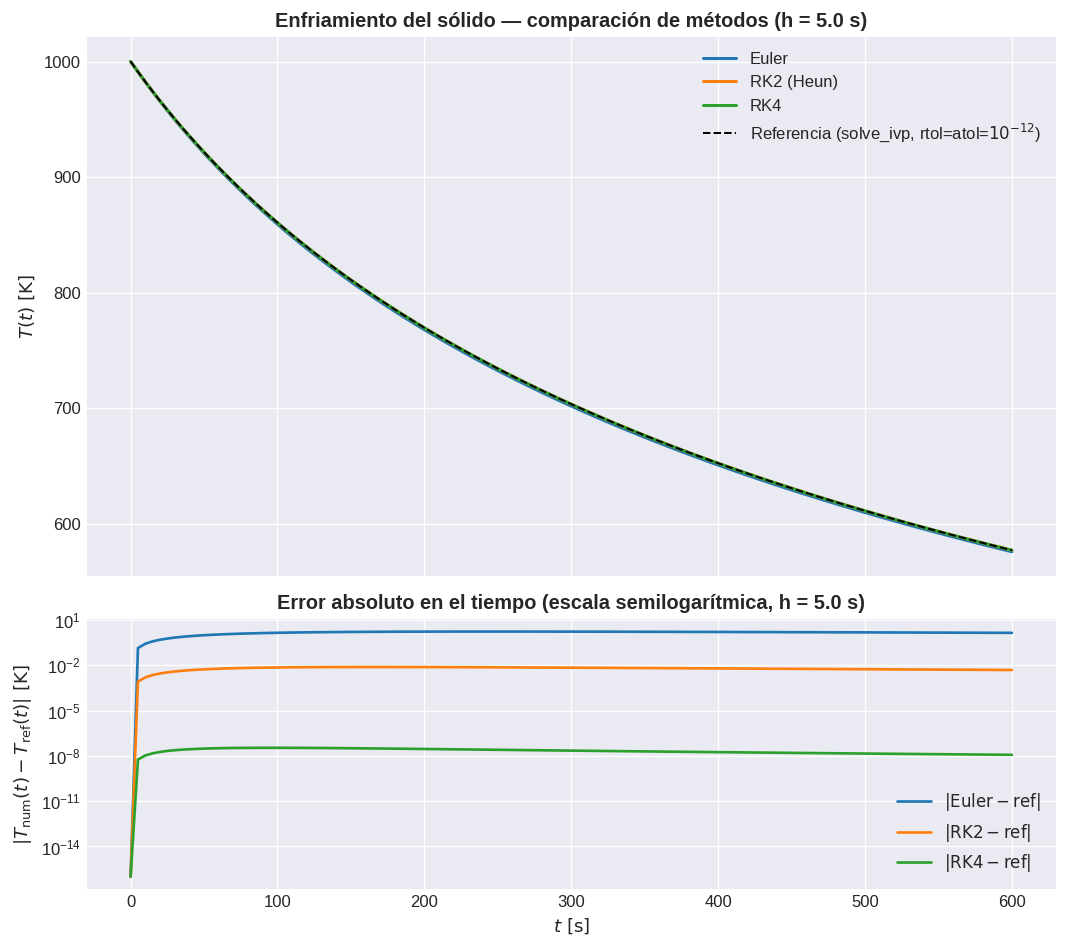


Errores máximos en [0, 600] s con h = 5.0 s:
  Euler : 1.6754e+00 K
  RK2   : 7.5617e-03 K
  RK4   : 3.4015e-08 K


In [ ]:
# Comparación visual: Euler vs RK2 vs RK4 vs solve_ivp (referencia)
# Dos subgráficas:
#   (a) Soluciones T(t)
#   (b) Error absoluto |T_num(t) - T_ref(t)| en escala semilogarítmica

h_comp = 5.0  # Paso representativo para la comparación cualitativa [s]

# --- Integración con los tres métodos ---
t_eu, y_eu = euler(f_modelo, T_INICIAL, T_FINAL, T0, h_comp)
t_r2, y_r2 = rk2  (f_modelo, T_INICIAL, T_FINAL, T0, h_comp)
t_r4, y_r4 = rk4  (f_modelo, T_INICIAL, T_FINAL, T0, h_comp)

# --- Solución de referencia de altísima precisión (rtol = atol = 1e-12) ---
# Se habilita dense_output para poder evaluar la referencia en cualquier t.
sol_ref = solve_ivp(
    f_modelo, [T_INICIAL, T_FINAL], [T0],
    method="RK45", rtol=1e-12, atol=1e-12,
    dense_output=True, max_step=1.0,
)

# Evaluación de la referencia en cada malla numérica
T_ref_eu = sol_ref.sol(t_eu).ravel()
T_ref_r2 = sol_ref.sol(t_r2).ravel()
T_ref_r4 = sol_ref.sol(t_r4).ravel()

# --- Figura con dos subgráficas apiladas ---
fig, axes = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# (a) Soluciones
axes[0].plot(t_eu,      y_eu,          label="Euler", linewidth=1.8)
axes[0].plot(t_r2,      y_r2,          label="RK2 (Heun)", linewidth=1.8)
axes[0].plot(t_r4,      y_r4,          label="RK4", linewidth=1.8)
axes[0].plot(sol_ref.t, sol_ref.y[0],  "k--", linewidth=1.2,
             label=r"Referencia (solve_ivp, rtol=atol=$10^{-12}$)")
axes[0].set_ylabel(r"$T(t)\ \mathrm{[K]}$")
axes[0].set_title(f"Enfriamiento del sólido — comparación de métodos (h = {h_comp} s)")
axes[0].legend(loc="best")

# (b) Error absoluto vs referencia, escala semilogarítmica
err_eu = np.abs(y_eu - T_ref_eu)
err_r2 = np.abs(y_r2 - T_ref_r2)
err_r4 = np.abs(y_r4 - T_ref_r4)

# Piso numérico para evitar log(0) al graficar
FLOOR = 1e-16

axes[1].semilogy(t_eu, err_eu + FLOOR, label=r"$|\mathrm{Euler} - \mathrm{ref}|$", linewidth=1.6)
axes[1].semilogy(t_r2, err_r2 + FLOOR, label=r"$|\mathrm{RK2} - \mathrm{ref}|$",   linewidth=1.6)
axes[1].semilogy(t_r4, err_r4 + FLOOR, label=r"$|\mathrm{RK4} - \mathrm{ref}|$",   linewidth=1.6)
axes[1].set_xlabel(r"$t\ \mathrm{[s]}$")
axes[1].set_ylabel(r"$|T_{\mathrm{num}}(t) - T_{\mathrm{ref}}(t)|\ \mathrm{[K]}$")
axes[1].set_title(f"Error absoluto en el tiempo (escala semilogarítmica, h = {h_comp} s)")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

# Reporte numérico resumen
print(f"\nErrores máximos en [0, {T_FINAL:.0f}] s con h = {h_comp} s:")
print(f"  Euler : {err_eu.max():.4e} K")
print(f"  RK2   : {err_r2.max():.4e} K")
print(f"  RK4   : {err_r4.max():.4e} K")


## 5. Estudio empírico de convergencia

Para verificar empíricamente las pendientes teóricas $p\in\{1,2,4\}$, se repite la integración con seis valores de $h$ en progresión geométrica estricta de razón $2$:

$$
h \in \{20,\; 10,\; 5,\; 2.5,\; 1.25,\; 0.625\}\ \mathrm{s}.
$$

Para cada $h$ y cada método se calcula el error global máximo

$$
E(h) \;=\; \max_{n}\,\bigl|\,T(t_n) - T_n\,\bigr|,
$$

usando como $T(t_n)$ la solución de referencia de `solve_ivp` a tolerancia $10^{-12}$ evaluada vía interpolación densa. Las pendientes empíricas se estiman por regresión lineal con `np.polyfit` sobre $(\log h,\log E)$. Adicionalmente se tabula el factor de reducción $E(h)/E(h/2)$, que para un método de orden $p$ debe tender a $2^p$ (valores esperados: $2$, $4$, $16$).


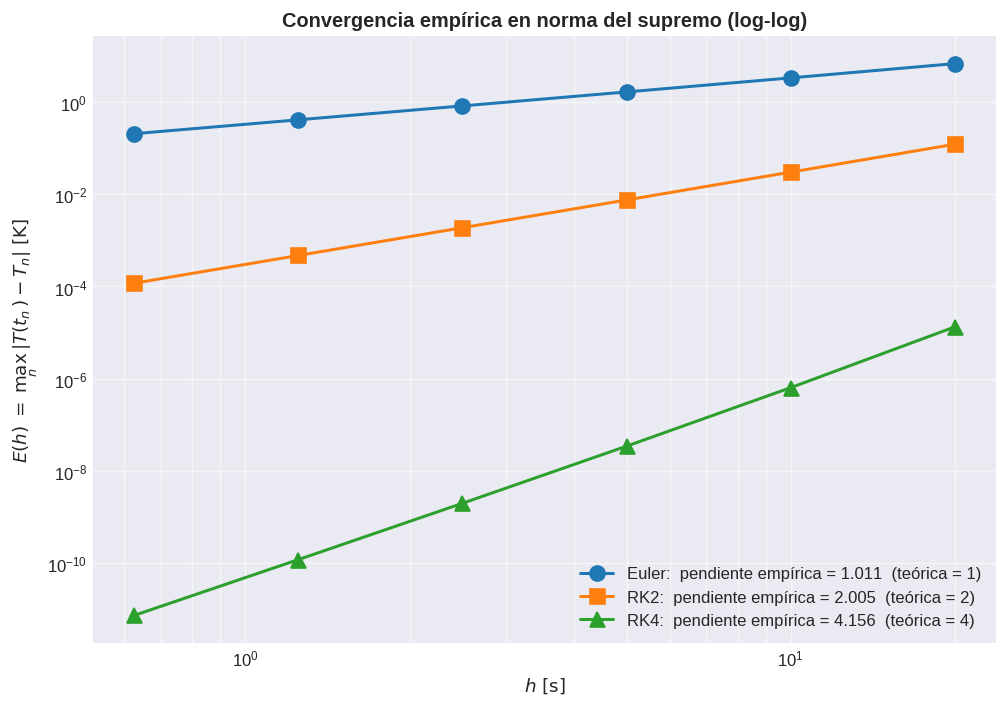


Tabla de errores globales máximos y factores de reducción  E(h) / E(h/2):
(Factor esperado:  Euler ≈ 2,   RK2 ≈ 4,   RK4 ≈ 16)

       h    E_Euler Fact_Euler      E_RK2  Fact_RK2      E_RK4  Fact_RK4
 20.0000 6.9147e+00      —     1.2275e-01     —     1.3288e-05     —    
 10.0000 3.3852e+00      2.043 3.0407e-02     4.037 6.3576e-07    20.901
  5.0000 1.6754e+00      2.021 7.5617e-03     4.021 3.4015e-08    18.691
  2.5000 8.3351e-01      2.010 1.8849e-03     4.012 1.9530e-09    17.417
  1.2500 4.1572e-01      2.005 4.7049e-04     4.006 1.1676e-10    16.727
  0.6250 2.0760e-01      2.002 1.1753e-04     4.003 7.1623e-12    16.302

COMPARACIÓN DE PENDIENTES EMPÍRICAS vs TEÓRICAS
  Euler :  empírica = +1.0107  |  teórica = 1  |  error relativo =  1.07 %
  RK2   :  empírica = +2.0054  |  teórica = 2  |  error relativo =  0.27 %
  RK4   :  empírica = +4.1563  |  teórica = 4  |  error relativo =  3.91 %

Orden de convergencia empírico (redondeado):
  Euler  -->  p ≈ 1
  RK2    -->  p ≈ 2


In [ ]:
# Estudio empírico de convergencia
# 6 valores de h en progresión geométrica estricta de razón 2.
# Referencia : solve_ivp con rtol = atol = 1e-12 (reutilizada de la celda previa).
# Métrica    : error global máximo  E(h) = max_n |T(t_n) - T_n|.

H_VALORES = [20.0, 10.0, 5.0, 2.5, 1.25, 0.625]  # razón 2

errores = {"Euler": [], "RK2": [], "RK4": []}

for h in H_VALORES:
    # Integración con cada método al paso h
    t_eu, y_eu = euler(f_modelo, T_INICIAL, T_FINAL, T0, h)
    t_r2, y_r2 = rk2  (f_modelo, T_INICIAL, T_FINAL, T0, h)
    t_r4, y_r4 = rk4  (f_modelo, T_INICIAL, T_FINAL, T0, h)

    # Referencia evaluada en cada malla
    ref_eu = sol_ref.sol(t_eu).ravel()
    ref_r2 = sol_ref.sol(t_r2).ravel()
    ref_r4 = sol_ref.sol(t_r4).ravel()

    # Error global máximo (norma del supremo)
    errores["Euler"].append(np.max(np.abs(y_eu - ref_eu)))
    errores["RK2"  ].append(np.max(np.abs(y_r2 - ref_r2)))
    errores["RK4"  ].append(np.max(np.abs(y_r4 - ref_r4)))

# --- Pendientes empíricas por regresión lineal en log-log ---
log_h = np.log(H_VALORES)
pendientes = {}
for metodo in ["Euler", "RK2", "RK4"]:
    log_e = np.log(errores[metodo])
    m, _b = np.polyfit(log_h, log_e, 1)
    pendientes[metodo] = m

pend_teor = {"Euler": 1, "RK2": 2, "RK4": 4}

# --- Gráfica log-log ---
fig, ax = plt.subplots(figsize=(8.5, 6))
marcadores = {"Euler": "o", "RK2": "s", "RK4": "^"}

for metodo in ["Euler", "RK2", "RK4"]:
    etiqueta = (f"{metodo}:  pendiente empírica = {pendientes[metodo]:.3f}  "
                f"(teórica = {pend_teor[metodo]})")
    ax.loglog(H_VALORES, errores[metodo],
              marker=marcadores[metodo], linestyle="-",
              linewidth=1.8, markersize=9, label=etiqueta)

ax.set_xlabel(r"$h\ \mathrm{[s]}$")
ax.set_ylabel(r"$E(h)\;=\;\max_{n}\,|T(t_n)-T_n|\ \mathrm{[K]}$")
ax.set_title("Convergencia empírica en norma del supremo (log-log)")
ax.grid(True, which="both", alpha=0.6)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# --- Tabla de errores y factores de reducción E(h)/E(h/2) ---
df = pd.DataFrame({"h": H_VALORES})
for metodo in ["Euler", "RK2", "RK4"]:
    df[f"E_{metodo}"] = errores[metodo]
    factores = [np.nan] + [errores[metodo][i - 1] / errores[metodo][i]
                           for i in range(1, len(H_VALORES))]
    df[f"Fact_{metodo}"] = factores

# Formateadores columna por columna
def _fmt_fact(x):
    return "    —    " if (x is None or (isinstance(x, float) and np.isnan(x))) else f"{x:8.3f}"

formatters = {
    "h":          lambda x: f"{x:8.4f}",
    "E_Euler":    lambda x: f"{x:.4e}",
    "E_RK2":      lambda x: f"{x:.4e}",
    "E_RK4":      lambda x: f"{x:.4e}",
    "Fact_Euler": _fmt_fact,
    "Fact_RK2":   _fmt_fact,
    "Fact_RK4":   _fmt_fact,
}

print("\nTabla de errores globales máximos y factores de reducción  E(h) / E(h/2):")
print("(Factor esperado:  Euler ≈ 2,   RK2 ≈ 4,   RK4 ≈ 16)\n")
print(df.to_string(index=False, formatters=formatters, na_rep="    —    "))

# --- Comparación cuantitativa: pendientes empíricas vs teóricas ---
print("\n" + "=" * 66)
print("COMPARACIÓN DE PENDIENTES EMPÍRICAS vs TEÓRICAS")
print("=" * 66)
for metodo in ["Euler", "RK2", "RK4"]:
    emp = pendientes[metodo]
    teo = pend_teor[metodo]
    err_pct = 100.0 * abs(emp - teo) / teo
    print(f"  {metodo:6s}:  empírica = {emp:+.4f}  |  teórica = {teo}  |  "
          f"error relativo = {err_pct:5.2f} %")
print("=" * 66)

# Resumen final "en caja" del orden de convergencia verificado
print("\nOrden de convergencia empírico (redondeado):")
print(f"  Euler  -->  p ≈ {round(pendientes['Euler'])}")
print(f"  RK2    -->  p ≈ {round(pendientes['RK2'])}")
print(f"  RK4    -->  p ≈ {round(pendientes['RK4'])}")


## 6. Conclusiones

A lo largo de este proyecto se planteó y resolvió numéricamente el problema
de enfriamiento de una pieza metálica que pierde calor por convección y
radiación al mismo tiempo. Estas son las conclusiones principales que saqué
del trabajo:

**1. El modelo no lineal sí importa.**

Al inicio de la simulación, la pieza está a 1000 K y el término de radiación
es aproximadamente 3.2 veces más fuerte que el de convección. Lo que más me
llamó la atención fue ver en la gráfica de error que todos los métodos se
equivocan más en esos primeros segundos y no al final, que era lo que yo
hubiera esperado. Tiene sentido cuando uno lo piensa: la temperatura cambia
muy rápido al inicio porque la radiación es muy intensa, entonces es más
difícil para cualquier método seguirle el ritmo. Conforme la pieza se enfría,
la ecuación se vuelve más "tranquila" y el error se estabiliza.

**2. La teoría y los resultados coinciden.**

Las pendientes que se obtienen experimentalmente en la gráfica log-log son
prácticamente iguales a las que predice la teoría de Series de Taylor: 1 para
Euler, 2 para RK2 y 4 para RK4, con desviaciones menores al 4%. Los factores
de reducción de la tabla también lo confirman cada vez que se reduce el paso
a la mitad, el error de RK4 se divide entre aproximadamente 16, que es
exactamente $2^4$. Para mí eso fue la confirmación de que la matemática de la
sección 2 no es solo teoría sino que se puede verificar directamente con el
computador.

**3. ¿Cuándo usar cada método?**

Después de ver los resultados, creo que la elección del método depende de qué
tan preciso necesitas ser. Si solo quieres una idea general de cómo evoluciona
el sistema, Euler es suficiente y es el más fácil de entender e implementar.
Si necesitas algo más preciso sin complicar mucho el código, RK2 es una buena
opción intermedia. Para trabajo serio donde el error importa, RK4 es
claramente el mejor con el mismo tamaño de paso su error es millones de
veces menor que el de Euler.

**4. ¿Qué seguiría después?**

Una extensión interesante sería considerar que el coeficiente de convección
no es constante sino que cambia con la temperatura, lo cual es más realista.
También se podría relajar la hipótesis de que toda la pieza tiene la misma
temperatura, que es lo que asumimos desde el principio — en ese caso ya no
bastaría con una ecuación diferencial ordinaria y habría que resolver algo
más complejo.

## 7. Referencias

- Zill, D. G. (2018). *Ecuaciones diferenciales con problemas de valores
  en la frontera* (9.ª ed.). Cengage Learning.
  *(Capítulo 1 para la formulación del PVI y sección 2.2 para separación
  de variables, usadas en las secciones 1.3 y 1.5 del cuaderno.)*

- Chapra, S. C., & Canale, R. P. (2015). *Métodos numéricos para
  ingenieros* (7.ª ed.). McGraw-Hill Education.
  *(Capítulo 25, secciones 25.1–25.3: esquemas de Euler, RK2 y RK4 y
  deducción del error por series de Taylor, base de la sección 2.)*

- Bergman, T. L., Lavine, A. S., Incropera, F. P., & DeWitt, D. P.
  (2011). *Fundamentals of heat and mass transfer* (7th ed.).
  John Wiley & Sons.
  *(Capítulo 5, secciones 5.1–5.2: hipótesis de lumped capacitance y
  número de Biot. Tablas A.1 y A.11: valores de h, ρ, c, k y ε
  usados en la sección 1.6.)*

- NumPy: `np.linspace`, `np.empty`, `np.abs`, `np.max`, `np.log`,
  `np.polyfit` — https://numpy.org/doc/stable/reference/

- SciPy: `scipy.integrate.solve_ivp` —
  https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

- Matplotlib: `pyplot.subplots`, `Axes.semilogy`, `Axes.loglog` —
  https://matplotlib.org/stable/api/